In [87]:
# 한글 폰트 설정 (윈도우용)
import matplotlib.font_manager as font_manager
font_path = "C:/Windows/Fonts/malgun.ttf"  # 'Malgun Gothic' 폰트 경로
font_prop = font_manager.FontProperties(fname=font_path)

In [89]:
pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [188]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import pandas as pd
import time
import pymysql

# 📌 1. 셀레니움 설정 및 페이지 요청
options = Options()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(service=Service(), options=options)
driver.get("https://store.kyobobook.co.kr/bestseller/realtime")
time.sleep(3)

soup = BeautifulSoup(driver.page_source, "html.parser")
driver.quit()

# 📌 2. 크롤링된 책 정보 파싱
book_items = soup.select("li.mt-9.flex")[:10]
books = []

for item in book_items:
    try:
        title = item.select_one("a.prod_link.line-clamp-2").get_text(strip=True)
        author_info = item.select_one("div.line-clamp-2.flex").get_text(" ", strip=True)
        author, publisher, pub_date = "", "", ""
        parts = author_info.split("·")
        if len(parts) >= 2:
            author = parts[0].strip()
            publisher = parts[1].strip()
        if len(parts) >= 3:
            pub_date = parts[2].strip()
        price_origin = item.select_one("s.text-gray-700").get_text(strip=True) if item.select_one("s.text-gray-700") else ""
        description = item.select_one("p.prod_introduction").get_text(" ", strip=True) if item.select_one("p.prod_introduction") else ""
        review_score = item.select_one("span.font-bold.text-black").get_text(strip=True) if item.select_one("span.font-bold.text-black") else ""
        review_count = item.select_one("span.font-normal.text-gray-700").get_text(strip=True) if item.select_one("span.font-normal.text-gray-700") else ""

        books.append({
            "제목": title,
            "저자": author,
            "출판사": publisher,
            "출간일": pub_date,
            "정가": price_origin.replace("원", "").replace(",", ""),
            "설명": description,
            "리뷰점수": review_score,
            "리뷰개수": review_count.replace("(", "").replace("개의 리뷰)", "")
        })
    except Exception as e:
        continue

df = pd.DataFrame(books)

for _, row in df.iterrows():
    price = row["정가"].replace(",", "").strip()
    review_score = row["리뷰점수"].strip()
    review_count = row["리뷰개수"].replace(",", "").replace("(", "").replace("개의 리뷰)", "").strip()  # ✅ 쉼표 제거 추가

    cur.execute(insert_sql, (
        row["제목"],
        row["저자"],
        row["출판사"],
        row["출간일"],
        int(float(price)) if price else None,
        row["설명"],
        float(review_score) if review_score else None,
        int(float(review_count)) if review_count else None
    ))


# 📌 CSV 파일로 저장
df.to_csv("bestsellers.csv", index=False, encoding="utf-8-sig")
print("✅ CSV 파일 저장 완료: bestsellers.csv")

✅ DB에 저장 완료 (중복은 자동 제외)
✅ CSV 파일 저장 완료: bestsellers.csv


In [131]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

headers = {
    "User-Agent": "Mozilla/5.0"
}

url = "https://store.kyobobook.co.kr/bestseller/realtime"
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# 책 정보 블럭 가져오기
book_items = soup.select("li.mt-9.flex")[:10]  # 상위 10개만

books = []

for item in book_items:
    try:
        title = item.select_one("a.prod_link.line-clamp-2").get_text(strip=True)
        author_info = item.select_one("div.line-clamp-2.flex").get_text(" ", strip=True)
        author, publisher, pub_date = "", "", ""
        parts = author_info.split("·")
        if len(parts) >= 2:
            author = parts[0].strip()
            publisher = parts[1].strip()
        if len(parts) >= 3:
            pub_date = parts[2].strip()
        price_origin = item.select_one("s.text-gray-700").get_text(strip=True) if item.select_one("s.text-gray-700") else ""
        description = item.select_one("p.prod_introduction").get_text(" ", strip=True) if item.select_one("p.prod_introduction") else ""
        review_score = item.select_one("span.font-bold.text-black").get_text(strip=True) if item.select_one("span.font-bold.text-black") else ""
        review_count = item.select_one("span.font-normal.text-gray-700").get_text(strip=True) if item.select_one("span.font-normal.text-gray-700") else ""

        books.append({
            "제목": title,
            "저자": author,
            "출판사": publisher,
            "출간일": pub_date,
            "정가": price_origin,
            "설명": description,
            "리뷰점수": review_score,
            "리뷰개수": review_count
        })
    except Exception as e:
        continue

# DataFrame 변환
df = pd.DataFrame(books)
df

                       제목   리뷰개수
0              결국 국민이 합니다  201.0
1           행복은 언제나 당신의 편    NaN
2                단 한 번의 삶   83.0
3    잠시 쉬어 가세요, 런던의 심리상담실    4.0
4    대통령 윤석열 탄핵 사건 선고 결정문   91.0
5            인생의 파도를 넘는 법    NaN
6  타인에게 기대하지 않는 삶을 위한 안내서    5.0
7       마흔 고비에 꼭 만나야 할 장자   24.0
8                  듀얼 브레인   67.0
9       예약판매줬으면 그만이지(반양장)   68.0


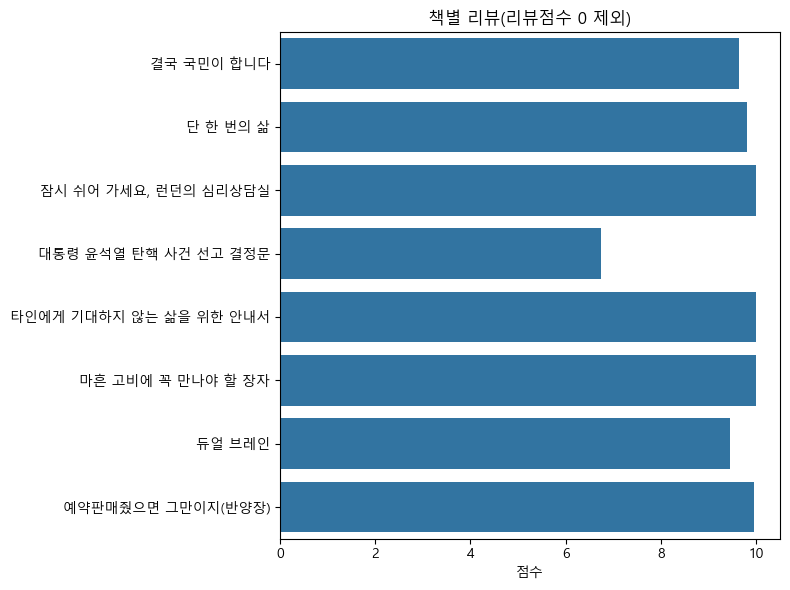

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (윈도우용)
plt.rcParams['font.family'] = 'Malgun Gothic'

df['리뷰점수'] = pd.to_numeric(df['리뷰점수'], errors='coerce')
df_filtered = df[df['리뷰점수'] > 0]

plt.figure(figsize=(8, 6))
sns.barplot(data=df_filtered, y='제목', x='리뷰점수', orient='h')
plt.title('책별 리뷰(리뷰점수 0 제외)')
plt.ylabel('')
plt.xlabel('점수')
plt.tight_layout()
plt.show()

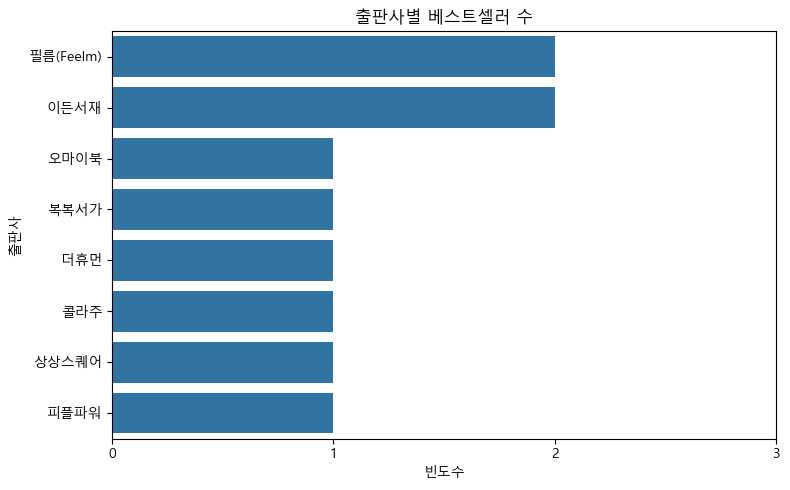

In [161]:
plt.figure(figsize=(8, 5))
plt.xlabel('빈도수', fontproperties=font_prop)  # 직접 지정
sns.countplot(data=df, y='출판사', order=df['출판사'].value_counts().index)
plt.title('출판사별 베스트셀러 수')

# ✅ x축 눈금 1단위로 설정
max_val = df['출판사'].value_counts().max()
plt.xticks(ticks=range(0, max_val+2, 1))  # 최대값 기준으로 1씩 증가

plt.tight_layout()
plt.show()

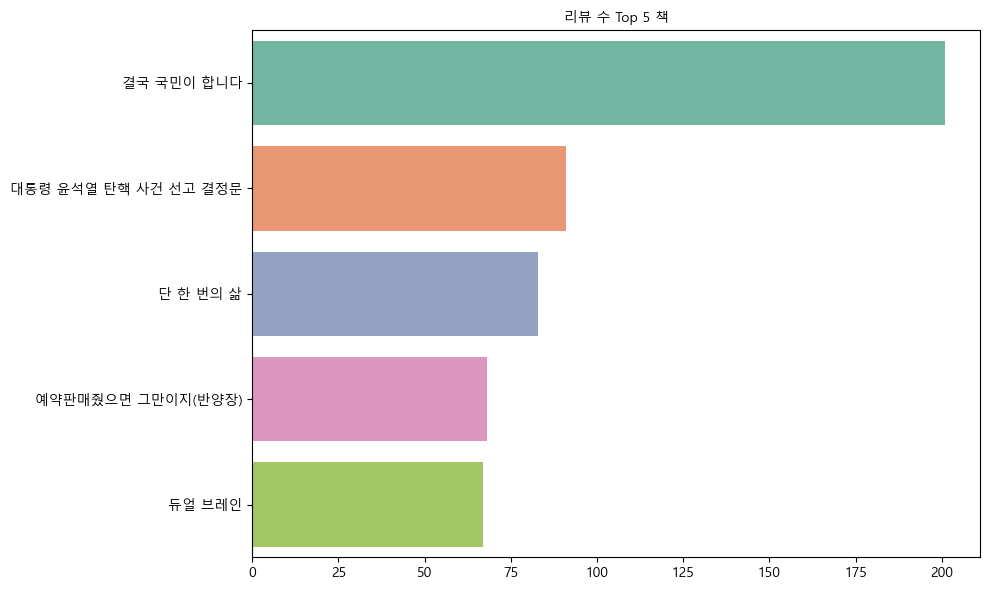

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as font_manager
import matplotlib as mpl
import pandas as pd

# 📌 예시용 데이터프레임 불러오기 (이미 MySQL에서 가져온 상태라고 가정)
# df = pd.read_sql("SELECT * FROM bestsellers", con=engine)

# 🔤 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['axes.unicode_minus'] = False


df['리뷰개수'] = df['리뷰개수'].astype(str)
df['리뷰개수'] = df['리뷰개수'].str.extract(r'(\d+)')
df['리뷰개수'] = pd.to_numeric(df['리뷰개수'], errors='coerce')

# ✅ 리뷰 많은 Top 5 추출
top5_reviews = df.sort_values(by='리뷰개수', ascending=False).head(5)

# ✅ 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=top5_reviews, y='제목', x='리뷰개수', hue='제목', palette='Set2', legend=False)
plt.title('리뷰 수 Top 5 책', fontproperties=font_prop)
plt.ylabel('')  # y축 라벨 제거
plt.xlabel('')  # x축 라벨 제거
plt.tight_layout()
plt.show()